### from https://github.com/nickdelgrosso/XCaliburMethodReader/tree/master

In [363]:
import olefile
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
%matplotlib inline

In [364]:
%load_ext autoreload
%autoreload 2

from vneo_method_parser import LCMethod
from lc_method_collection import LCMethodCollection
from ms_method_parser import MSMethod


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [365]:
meth_file = '/Users/eileen.wang/Desktop/diann/SampleData/methods/LC/10m150nlRainmanA15-75.meth'
method = LCMethod(meth_file)

/Users/eileen.wang/Desktop/diann/code/vneo_method_parser.py:109: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  gradient_df[col] = pd.to_numeric(gradient_df[col], errors='ignore')
/Users/eileen.wang/Desktop/diann/code/vneo_method_parser.py:112: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  equil_df[col] = pd.to_numeric(equil_df[col], errors='ignore')


In [366]:
collection = LCMethodCollection()
collection.add_methods_from_folder('/Users/eileen.wang/Desktop/diann/SampleData/methods/LC')

In [367]:
collection.methods.keys()

dict_keys(['20m150nlv15', '23p75m150nlv16', '17p5m150nlv13', '36m150nlLong40', '25m150nlv5', '17p7m150nlv11', '25m200nlv5', '10m150nlRainmanA15-75', '20m150nlML23p5mA15v1', '25m150nlv4', '16m150nlv8', '23p75mHighACNWash150nlv17', '20p5m150nlv7', '20p5m150nlv6', '20m150nlML30mA15phospho4', '17p5m150nlv10', '20p5m150nlv14', '23p65m150nlv18Zebra', '11p5m150nlv9', '24m150nlThermo', '36m150nlSlow40', '27m150nlv3', '17p75m150nlv12', '20m150nlML30mA15v2'])

In [368]:
df = collection.compare_gradients(['20m150nlv15', '23p75m150nlv16'])

In [369]:
df

,time [min],Neo.PumpModule.Pump.Flow.Nominal [µl/min],Neo.PumpModule.Pump.%B.Value [%],Neo.PumpModule.Pump.Curve,Method
0,0.00,0.60,2.0,5,20m150nlv15
1,1.00,0.60,12.0,5,20m150nlv15
2,1.50,0.15,13.5,5,20m150nlv15
3,8.50,0.15,30.0,5,20m150nlv15
4,13.00,0.15,45.0,5,20m150nlv15
5,15.00,0.15,95.0,5,20m150nlv15
6,17.00,0.15,95.0,5,20m150nlv15
7,18.00,1.00,50.0,5,20m150nlv15
8,20.00,1.00,50.0,5,20m150nlv15
9,0.00,0.60,2.0,5,23p75m150nlv16


<Axes: xlabel='time [min]', ylabel='Neo.PumpModule.Pump.%B.Value [%]'>

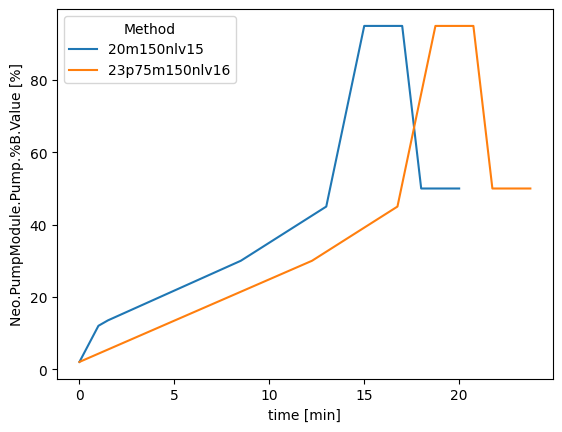

In [370]:
sns.lineplot(data = df, x = 'time [min]', y='Neo.PumpModule.Pump.%B.Value [%]', hue='Method')


(array([-5.,  0.,  5., 10., 15., 20., 25.]),
 [Text(-5.0, 0, '−5'),
  Text(0.0, 0, '0'),
  Text(5.0, 0, '5'),
  Text(10.0, 0, '10'),
  Text(15.0, 0, '15'),
  Text(20.0, 0, '20'),
  Text(25.0, 0, '25')])

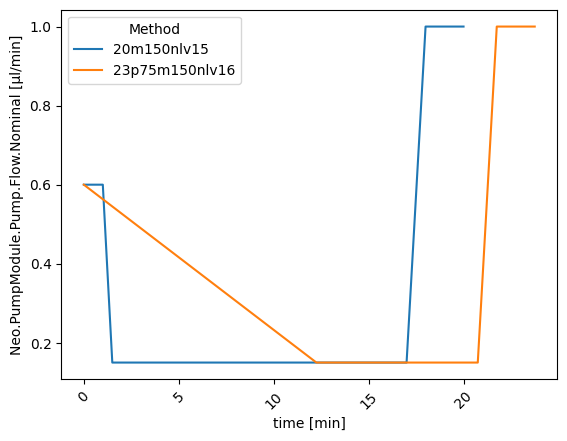

In [371]:
sns.lineplot(data = df, x = 'time [min]', y='Neo.PumpModule.Pump.Flow.Nominal [µl/min]', hue='Method')
plt.xticks(rotation=45)

In [388]:
# Load unified Bruker method parser
from bruker_method import BrukerMethod

# Parse complete method (MS parameters + DIA settings)
method = BrukerMethod('/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m')

# For backward compatibility with existing notebook cells
dia_settings = method.dia  # Expose DIASettings object
ms_method = method.ms      # Expose MSMethod object

# Print comprehensive summary
print(method.summary())

# Show how to access data
print("\n" + "=" * 80)
print("ACCESSING DATA")
print("=" * 80)

print("\n1. MS Parameters (via convenience methods):")
print(f"   Collision Gas Supply: {method.get_param('Collision_GasSupply_Set')}")
print(f"   Capillary Voltage (ESI, Negative): {method.get_param('Source_CapillarySetValue', polarity='negative', source='esi')} V")

print("\n2. DIA Windows (via convenience methods):")
dia_windows = method.get_dia_windows()
if dia_windows is not None:
    print(f"   Total DIA windows: {len(dia_windows)}")
    print(f"   First window: {dia_windows.iloc[0]['MzStart']:.1f} - {dia_windows.iloc[0]['MzEnd']:.1f} m/z")

print("\n3. Three ways to access the same data:")
print(f"   method.get_dia_windows()      -> Convenience method")
print(f"   method.dia.get_dia_windows()  -> Via sub-parser")
print(f"   dia_settings.get_dia_windows() -> Backward compatible alias")

print("\n✓ Unified method object loaded successfully!")

BRUKER TIMSTOF METHOD SUMMARY

Method Directory: DIA003.proteoscape.m

MS INSTRUMENT PARAMETERS
Global parameters: 35
Polarities configured: negative, positive

Key Global Parameters:
  Digitizer_SampleIntervall: 0.2
  Collision_GasSupply_Set: 58.0
  TOF_DetectorTofSetValue: 2252.0

Capillary Voltages (Negative Mode, ESI):

DIA ACQUISITION SETTINGS
Total windows: 17
MS1 windows: 1
DIA windows: 16

DIA Window Ranges:
  m/z: 319.2 - 1440.0
  1/K0 (Ion Mobility): 0.70 - 1.30
  Unique cycles: 9 (0 - 8)


ACCESSING DATA

1. MS Parameters (via convenience methods):
   Collision Gas Supply: 58.0
   Capillary Voltage (ESI, Negative): None V

2. DIA Windows (via convenience methods):
   Total DIA windows: 16
   First window: 741.3 - 779.9 m/z

3. Three ways to access the same data:
   method.get_dia_windows()      -> Convenience method
   method.dia.get_dia_windows()  -> Via sub-parser
   dia_settings.get_dia_windows() -> Backward compatible alias

✓ Unified method object loaded successfully!


In [390]:
# Plot DIA windows using the built-in method with full customization options# Option 1: Default - Color by cycle with white edgesdia_settings.plot_windows()plt.tight_layout()plt.show()# Option 2: Uniform colordia_settings.plot_windows(color_by_cycle=False, uniform_color='coral')plt.tight_layout()plt.show()# Option 3: Customize transparency and edge colordia_settings.plot_windows(alpha=0.8, edge_color='black')plt.tight_layout()plt.show()# Option 4: Multi-panel comparison with different stylesfig, axes = plt.subplots(2, 2, figsize=(16, 12))# Top-left: Color by cycle, white edges (default)dia_settings.plot_windows(ax=axes[0, 0], color_by_cycle=True,                          alpha=0.6, edge_color='white')axes[0, 0].set_title('Color by Cycle (white edges)', fontsize=11, fontweight='bold')# Top-right: Color by cycle, black edgesdia_settings.plot_windows(ax=axes[0, 1], color_by_cycle=True,                          alpha=0.7, edge_color='black')axes[0, 1].set_title('Color by Cycle (black edges)', fontsize=11, fontweight='bold')# Bottom-left: Uniform color, high transparencydia_settings.plot_windows(ax=axes[1, 0], color_by_cycle=False,                          uniform_color='steelblue', alpha=0.3, edge_color='white')axes[1, 0].set_title('Uniform Color (high transparency)', fontsize=11, fontweight='bold')# Bottom-right: Uniform color, low transparencydia_settings.plot_windows(ax=axes[1, 1], color_by_cycle=False,                          uniform_color='coral', alpha=0.9, edge_color='black')axes[1, 1].set_title('Uniform Color (low transparency)', fontsize=11, fontweight='bold')plt.tight_layout()plt.show()

,Id,Type,CycleId,OneOverK0Start,OneOverK0End,IsolationMz,IsolationWidth,CollisionEnergy,WindowType,MzStart,MzEnd
1,2,1,1,0.89,1.30,760.605,38.530,None,MS2/DIA,741.3400,779.8700
2,3,1,1,0.70,0.89,390.945,143.530,None,MS2/DIA,319.1800,462.7100
3,4,1,2,0.93,1.30,800.835,41.930,None,MS2/DIA,779.8700,821.8000
4,5,1,2,0.70,0.93,487.125,48.830,None,MS2/DIA,462.7100,511.5400
5,6,1,3,0.95,1.30,844.390,45.180,None,MS2/DIA,821.8000,866.9800
6,7,1,3,0.70,0.95,532.245,41.410,None,MS2/DIA,511.5400,552.9500
7,8,1,4,0.97,1.30,891.350,48.740,None,MS2/DIA,866.9800,915.7200
8,9,1,4,0.70,0.97,572.940,39.980,None,MS2/DIA,552.9500,592.9300
9,10,1,5,0.99,1.30,943.575,55.710,None,MS2/DIA,915.7200,971.4300
10,11,1,5,0.70,0.99,611.295,36.730,None,MS2/DIA,592.9300,629.6600


In [ ]:
# Example: Using method_name for better legends# Single method with namefig, axes = plt.subplots(1, 2, figsize=(16, 6))# With method name (useful for documentation/reports)dia_settings.plot_windows(ax=axes[0], method_name='DIA003.proteoscape',                          color_by_cycle=True, alpha=0.7)axes[0].set_title('With Method Name in Legend', fontsize=12, fontweight='bold')# Without method namedia_settings.plot_windows(ax=axes[1], color_by_cycle=True, alpha=0.7)axes[1].set_title('Without Method Name', fontsize=12, fontweight='bold')plt.tight_layout()plt.show()# Use case: Comparing multiple methods# (In real scenario, you'd load different method files)fig, ax = plt.subplots(figsize=(14, 8))# Method A (uniform color with name)dia_settings.plot_windows(ax=ax, method_name='Method A',                          color_by_cycle=False, uniform_color='steelblue',                         alpha=0.5, show_labels=False)# In real use: load method B and plot# method_b = DIASettings('/path/to/methodB.m')# method_b.plot_windows(ax=ax, method_name='Method B', #                      color_by_cycle=False, uniform_color='coral',#                      alpha=0.5, show_labels=False)ax.set_title('Method Comparison Example', fontsize=14, fontweight='bold')plt.tight_layout()plt.show()

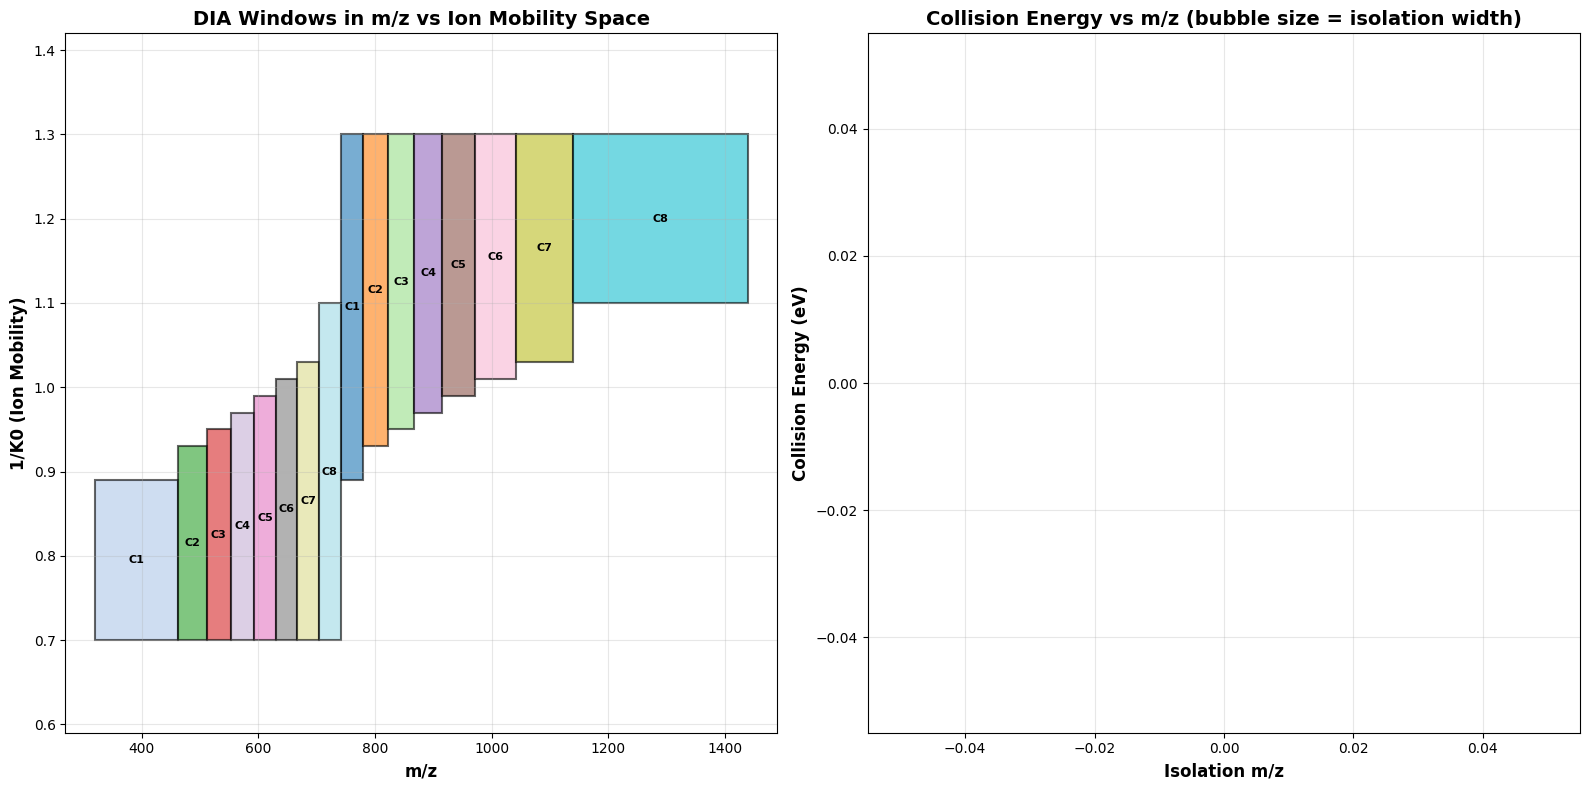


DIA Windows Summary (from SQLite):
Total DIA windows: 16
Unique cycles: 8
m/z range: 319.2 - 1440.0
1/K0 range: 0.64 - 1.37


In [386]:
# Visualize DIA windows in m/z vs 1/K0 space
dia_windows = dia_settings.get_dia_windows()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Left plot: Windows in m/z vs 1/K0 space
colors = plt.cm.tab20(np.linspace(0, 1, len(dia_windows)))

for i, (idx, row) in enumerate(dia_windows.iterrows()):
    # Draw rectangle for each window
    mz_start = row['MzStart']
    mz_end = row['MzEnd']
    k0_start = row['OneOverK0Start']
    k0_end = row['OneOverK0End']
    
    # Skip if any values are NaN
    if pd.isna([mz_start, mz_end, k0_start, k0_end]).any():
        continue
    
    # Create rectangle
    rect = plt.Rectangle((mz_start, k0_start), 
                         mz_end - mz_start, 
                         k0_end - k0_start,
                         facecolor=colors[i], 
                         edgecolor='black', 
                         alpha=0.6,
                         linewidth=1.5)
    ax1.add_patch(rect)
    
    # Add cycle ID label
    ax1.text((mz_start + mz_end) / 2, (k0_start + k0_end) / 2, 
            f'C{int(row["CycleId"])}', 
            ha='center', va='center', fontsize=8, fontweight='bold')

ax1.set_xlabel('m/z', fontsize=12, fontweight='bold')
ax1.set_ylabel('1/K0 (Ion Mobility)', fontsize=12, fontweight='bold')
ax1.set_title('DIA Windows in m/z vs Ion Mobility Space', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xlim(dia_windows['MzStart'].min() - 50, dia_windows['MzEnd'].max() + 50)
ax1.set_ylim(dia_settings.global_info['OneOverK0LowerLimit'] - 0.05, 
             dia_settings.global_info['OneOverK0UpperLimit'] + 0.05)

# Right plot: Collision energy by cycle
dia_windows_grouped = dia_windows.groupby('CycleId').agg({
    'IsolationMz': 'mean',
    'CollisionEnergy': 'mean',
    'IsolationWidth': 'mean'
}).reset_index()

ax2.scatter(dia_windows_grouped['IsolationMz'], 
           dia_windows_grouped['CollisionEnergy'], 
           s=dia_windows_grouped['IsolationWidth']*3,
           c=dia_windows_grouped['CycleId'], 
           cmap='viridis',
           alpha=0.7, 
           edgecolors='black', 
           linewidth=1.5)

for i, row in dia_windows_grouped.iterrows():
    ax2.annotate(f"C{int(row['CycleId'])}", 
                (row['IsolationMz'], row['CollisionEnergy']),
                fontsize=9, ha='center', va='center')

ax2.set_xlabel('Isolation m/z', fontsize=12, fontweight='bold')
ax2.set_ylabel('Collision Energy (eV)', fontsize=12, fontweight='bold')
ax2.set_title('Collision Energy vs m/z (bubble size = isolation width)', fontsize=14, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print("\nDIA Windows Summary (from SQLite):")
print(f"Total DIA windows: {len(dia_windows)}")
print(f"Unique cycles: {dia_windows['CycleId'].nunique()}")
print(f"m/z range: {dia_windows['MzStart'].min():.1f} - {dia_windows['MzEnd'].max():.1f}")
print(f"1/K0 range: {dia_settings.global_info['OneOverK0LowerLimit']:.2f} - {dia_settings.global_info['OneOverK0UpperLimit']:.2f}")
# if dia_windows['CollisionEnergy'].notna().any():
#     print(f"Collision energy range: {dia_wi

In [387]:
# Load unified Bruker method parser
from bruker_method import BrukerMethod

# Parse complete method (MS parameters + DIA settings)
method = BrukerMethod('/Users/eileen.wang/Desktop/diann/SampleData/methods/MS/DIA003.proteoscape.m')

# Print comprehensive summary
print(method.summary())

# Show how to access data
print("\n" + "=" * 80)
print("ACCESSING DATA")
print("=" * 80)

print("\n1. MS Parameters (via convenience methods):")
print(f"   Collision Gas Supply: {method.get_param('Collision_GasSupply_Set')}")
print(f"   Capillary Voltage (ESI, Negative): {method.get_param('Source_CapillarySetValue', polarity='negative', source='esi')} V")

print("\n2. DIA Windows (via convenience methods):")
dia_windows = method.get_dia_windows()
if dia_windows is not None:
    print(f"   Total DIA windows: {len(dia_windows)}")
    print(f"   First window: {dia_windows.iloc[0]['MzStart']:.1f} - {dia_windows.iloc[0]['MzEnd']:.1f} m/z")

print("\n3. Direct access to sub-parsers:")
print(f"   method.ms  -> MSMethod object with {len(method.ms.instrument_params)} parameters")
print(f"   method.dia -> DIASettings object with {len(method.dia.windows)} windows")

# print("\n✓ Unified method object loaded s

BRUKER TIMSTOF METHOD SUMMARY

Method Directory: DIA003.proteoscape.m

MS INSTRUMENT PARAMETERS
Global parameters: 35
Polarities configured: negative, positive

Key Global Parameters:
  Digitizer_SampleIntervall: 0.2
  Collision_GasSupply_Set: 58.0
  TOF_DetectorTofSetValue: 2252.0

Capillary Voltages (Negative Mode, ESI):

DIA ACQUISITION SETTINGS
Total windows: 17
MS1 windows: 1
DIA windows: 16

DIA Window Ranges:
  m/z: 319.2 - 1440.0
  1/K0 (Ion Mobility): 0.70 - 1.30
  Unique cycles: 9 (0 - 8)


ACCESSING DATA

1. MS Parameters (via convenience methods):
   Collision Gas Supply: 58.0
   Capillary Voltage (ESI, Negative): None V

2. DIA Windows (via convenience methods):
   Total DIA windows: 16
   First window: 741.3 - 779.9 m/z

3. Direct access to sub-parsers:
   method.ms  -> MSMethod object with 35 parameters
   method.dia -> DIASettings object with 17 windows
